# GP and embedding-system comparison (paper, Appendix A)

Six ways to compute the certified tube (two wind models × the paper's three embedding systems), all at
the **same** certificate: the tube's position bounds within **0.25 m** of the reference position (and
above the 0.3 m floor), position uncertainty $\delta = 0$.

| embedding system | what the tube accounts for | **TV-GPR** ($\epsilon = 0.25$) | **GPR** ($\epsilon = 0$) |
|---|---|---|---|
| (68)-(69) | first-order interaction of the state with the feedback $u$ **and** the disturbance $w$ | **A** (this package) | **D** |
| (66)-(67) | first order in $u$ only; disturbance bounded over the box $[\underline\gamma, \overline\gamma]$ | **E** | **C** |
| (64)-(65) | no first-order terms: input interval from the feedback law by interval arithmetic, disturbance over the box | **F** | **B** |

Along a row the **GP** changes (time-varying vs time-invariant) with the same embedding; down a column
the **embedding system** changes with the same GP. The GPR is TVGPR with $\epsilon = 0$ (Assumption 2:
the temporal kernel is then 1).

**Data.** *Numerical closed loop* (`px4_rta_mm_gpr.sim`, exact state, known wind, which **drifts over time**): calm and the paper's
evolving winds at ×0.3 / ×0.6 / ×1.0 with 3 seeds; the backup is **off**, so every variant flies the full
mission and the certification statistics cover the same task. *PX4 SITL*: 3 flights per variant, the
backup (PX4 LAND after 20 ms without a certified plan) **on**, as deployed, flown twice: with
$\delta = 0$ (section 2) and with the **5 cm model-mismatch margin** $\delta = 0.05$ m, the default since
(section 3). The SITL world has **no wind** (Gazebo `default.sdf`): there the GPs only learn a
steady offset, so SITL tests the model mismatch and the margin, not the time-varying wind.

Tables: best value per column ★, worst ▽.

**Metrics.** `cert_med_s` / `cert_p5_s`: how far ahead each plan is certified (median / 5th percentile);
`plans`: replans in the 20 s phase; `uncertified_pct`: control ticks without a certified plan;
`escape_pct` / `escape_max_m`: certified ticks where the vehicle's position (true state in the numerical
runs, EKF2 estimate in SITL) is **outside** the certified box by more than 1 mm, and the largest excursion;
`tube_halfwidth_025`: tube position half-width 0.25 s into each plan (smaller = tighter);
`rollout_ms_*`: compute time of one rollout.

In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
from px4_rta_mm_gpr import analysis as rta
rta.use_style()
pd.set_option('display.width', 220, 'display.max_columns', 40, 'display.precision', 3)
os.makedirs('figures', exist_ok=True)
DATA = 'log_files/comparison'
ORDER = list(rta.VARIANTS)                 # A, E, F (TV-GPR) | D, C, B (GPR)
SHORT = {v: v.split(':')[0] for v in ORDER}
EMB_NAME = {'uw': '(68)-(69)', 'u': '(66)-(67)', 'none': '(64)-(65)'}
GP_OF = {v: ('TV-GPR' if eps > 0 else 'GPR') for v, (eps, emb) in rta.VARIANTS.items()}
EMB_OF = {v: EMB_NAME[emb] for v, (eps, emb) in rta.VARIANTS.items()}

def grid(frame, metric, agg='mean', fmt='{:.3g}'):
    """metric as a table: rows = embedding system, columns = GP (one cell per variant, letter in brackets)."""
    t = frame.groupby('variant', observed=True)[metric].agg(agg)
    g = pd.DataFrame('', index=list(EMB_NAME.values()), columns=['TV-GPR', 'GPR'])
    for v, val in t.items():
        g.loc[EMB_OF[v], GP_OF[v]] = f"{fmt.format(val)} ({SHORT[v]})"
    g.index.name = f"{metric} ({agg})"
    return g
COLS = ['cert_med_s', 'cert_p5_s', 'plans', 'uncertified_pct', 'escape_pct', 'escape_max_m', 'tube_halfwidth_025',
        'rmse_y', 'rmse_altitude', 'lowest_certified_tube', 'rollout_ms_med', 'rollout_ms_p99']
BETTER = {'cert_med_s': 'max', 'cert_p5_s': 'max', 'plans': 'min', 'uncertified_pct': 'min', 'escape_pct': 'min',
          'escape_max_m': 'min', 'tube_halfwidth_025': 'min', 'rmse_y': 'min', 'rmse_altitude': 'min',
          'lowest_certified_tube': 'max', 'rollout_ms_med': 'min', 'rollout_ms_p99': 'min'}

def styled(df, cols=COLS, fmt='{:.3g}'):
    """Formatted table: best value per column marked ★, worst ▽ (no styling dependency, renders anywhere)."""
    cols = [c for c in cols if c in df.columns]
    out = df[cols].copy().astype(object)
    for c in cols:
        col = df[c].astype(float)
        best = worst = None
        if c in BETTER and not col.isna().all() and col.nunique() > 1:
            best = col.max() if BETTER[c] == 'max' else col.min()
            worst = col.min() if BETTER[c] == 'max' else col.max()
        out[c] = [fmt.format(v) + (' ★' if v == best else (' ▽' if v == worst else '')) if np.isfinite(v) else '-'
                  for v in col]
    return out

## 1. Numerical closed loop (backup off, 10 wind cases per variant)

In [2]:
RUN_SIMS = False   # True: re-run the 60 simulations (deterministic; ~15 min) instead of reading the CSV
if RUN_SIMS:
    from px4_rta_mm_gpr.sim import SimConfig, simulate, paper_winds, calm
    rows = []
    for v, (eps, emb) in rta.VARIANTS.items():
        for case, seed, k in [('calm', 0, None)] + [(f'winds x{k}', s, k) for k in (0.3, 0.6, 1.0) for s in (0, 1, 2)]:
            w = calm() if k is None else paper_winds(scale=2.0 * k, seed=seed)
            path = f"/tmp/cmp_{v[0]}_{case.replace(' ', '')}_{seed}.h5"
            r = simulate(SimConfig(duration=20.0, seed=seed, gp_epsilon=eps, embedding=emb, stop_on_backup=False),
                         winds=w, log_path=path)
            m = rta.comparison_metrics(rta.load(path)); m.update(variant=v, case=case, seed=seed,
                                                                  final_error_to_goal=r.summary['final_error_to_goal'])
            rows.append(m)
    num = pd.DataFrame(rows)
else:
    num = pd.read_csv(f'{DATA}/numerical/numerical_comparison.csv')
num = num[num['variant'].isin(ORDER)]
num['variant'] = pd.Categorical(num['variant'], ORDER, ordered=True)
print(f"{len(num)} runs; all completed the 20 s mission: {bool((num['uncertified_pct'].notna()).all())}")

60 runs; all completed the 20 s mission: True


### Overall (mean over the 10 wind cases)

In [3]:
overall = num.groupby('variant', observed=True)[COLS].mean()
overall.index = [SHORT[v] + ': ' + v.split(': ')[1] for v in overall.index]
styled(overall)

,cert_med_s,cert_p5_s,plans,uncertified_pct,escape_pct,escape_max_m,tube_halfwidth_025,rmse_y,rmse_altitude,lowest_certified_tube,rollout_ms_med,rollout_ms_p99
A: TV-GPR + (68)-(69),0.594 ▽,0.489,34.6,0,0 ★,0.000476,0.0254,0.00743 ★,0.00735,1.14,6.91,8.88
E: TV-GPR + (66)-(67),0.594 ▽,0.49,34.5,0,0 ★,0.000476,0.0254 ▽,0.00757,0.00728,1.13,4.36 ★,5.17 ★
F: TV-GPR + (64)-(65),0.596,0.498,34.4,0,0.03,0.000446 ★,0.025,0.00758,0.00712 ★,1.15 ★,6.58,7.81
D: GPR + (68)-(69),0.803,0.51,25.5 ★,0,36.8 ▽,0.0576,0.00259,0.0192,0.0213,1.1,7.34 ▽,9.67
C: GPR + (66)-(67),0.821 ★,0.511 ★,39.7,0,36.5,0.146,0.00242,0.0296,0.0358,1.08,6.19,10.6 ▽
B: GPR + (64)-(65),0.729,0.464 ▽,43.1 ▽,0,36.5,0.159 ▽,0.00239 ★,0.0328 ▽,0.0367 ▽,1.03 ▽,6.35,9.76


### Relative to A (the current code): ratio of means

In [4]:
rel = overall.div(overall.iloc[0])
styled(rel, fmt='{:.2f}x')

,cert_med_s,cert_p5_s,plans,uncertified_pct,escape_pct,escape_max_m,tube_halfwidth_025,rmse_y,rmse_altitude,lowest_certified_tube,rollout_ms_med,rollout_ms_p99
A: TV-GPR + (68)-(69),1.00x ▽,1.00x,1.00x,-,-,1.00x,1.00x,1.00x ★,1.00x,1.00x,1.00x,1.00x
E: TV-GPR + (66)-(67),1.00x ▽,1.00x,1.00x,-,-,1.00x,1.00x ▽,1.02x,0.99x,0.99x,0.63x ★,0.58x ★
F: TV-GPR + (64)-(65),1.00x,1.02x,0.99x,-,-,0.94x ★,0.98x,1.02x,0.97x ★,1.01x ★,0.95x,0.88x
D: GPR + (68)-(69),1.35x,1.04x,0.74x ★,-,-,121.18x,0.10x,2.58x,2.89x,0.96x,1.06x ▽,1.09x
C: GPR + (66)-(67),1.38x ★,1.05x ★,1.15x,-,-,306.21x,0.10x,3.98x,4.87x,0.94x,0.90x,1.19x ▽
B: GPR + (64)-(65),1.23x,0.95x ▽,1.25x ▽,-,-,333.49x ▽,0.09x ★,4.41x ▽,5.00x ▽,0.91x ▽,0.92x,1.10x


### The grid: GP (columns) × embedding system (rows)
Wind runs only (9 per variant; in calm air the GP has nothing to learn).

In [5]:
wind = num[num['case'] != 'calm']
for metric, agg in (('escape_pct', 'mean'), ('escape_max_m', 'max'), ('cert_med_s', 'mean'),
                    ('tube_halfwidth_025', 'mean'), ('rmse_y', 'mean'), ('rollout_ms_med', 'mean')):
    display(grid(wind, metric, agg))

,TV-GPR,GPR
escape_pct (mean),,
(68)-(69),0 (A),40.7 (D)
(66)-(67),0 (E),40.4 (C)
(64)-(65),0.0333 (F),40.4 (B)


,TV-GPR,GPR
escape_max_m (max),,
(68)-(69),0.000882 (A),0.102 (D)
(66)-(67),0.000882 (E),0.287 (C)
(64)-(65),0.00116 (F),0.281 (B)


,TV-GPR,GPR
cert_med_s (mean),,
(68)-(69),0.59 (A),0.78 (D)
(66)-(67),0.59 (E),0.799 (C)
(64)-(65),0.592 (F),0.697 (B)


,TV-GPR,GPR
tube_halfwidth_025 (mean),,
(68)-(69),0.0258 (A),0.00264 (D)
(66)-(67),0.0258 (E),0.00245 (C)
(64)-(65),0.0254 (F),0.00241 (B)


,TV-GPR,GPR
rmse_y (mean),,
(68)-(69),0.00811 (A),0.021 (D)
(66)-(67),0.00826 (E),0.0326 (C)
(64)-(65),0.00827 (F),0.0362 (B)


,TV-GPR,GPR
rollout_ms_med (mean),,
(68)-(69),6.93 (A),6.95 (D)
(66)-(67),4.34 (E),6.12 (C)
(64)-(65),6.79 (F),6.19 (B)


### By wind strength

In [6]:
num['wind'] = num['case'].str.replace('winds ', 'paper winds ')
by = num.groupby(['wind', 'variant'], observed=True)[['cert_med_s', 'plans', 'uncertified_pct', 'escape_pct',
                                                      'escape_max_m', 'tube_halfwidth_025', 'rmse_y']].mean()
by

cert_med_s   plans  uncertified_pct  escape_pct  escape_max_m  tube_halfwidth_025  rmse_y
wind             variant                                                                                                         
calm             A: TV-GPR + (68)-(69)       0.630  32.000              0.0       0.000     0.000e+00               0.022   0.001
                 E: TV-GPR + (66)-(67)       0.630  32.000              0.0       0.000     0.000e+00               0.022   0.001
                 F: TV-GPR + (64)-(65)       0.630  32.000              0.0       0.000     0.000e+00               0.021   0.001
                 D: GPR + (68)-(69)          1.015  16.000              0.0       1.500     3.234e-03               0.002   0.002
                 C: GPR + (66)-(67)          1.015  16.000              0.0       1.500     3.234e-03               0.002   0.002
                 B: GPR + (64)-(65)          1.015  16.000              0.0       1.500     3.298e-03               0.002   0.002
paper winds x0.3 A: TV-GPR + (68)-(69)       0.617  33.333              0.0       0.000     2.005e-04               0.023   0.004
                 E: TV-GPR + (66)-(67)       0.617  33.333              0.0       0.000     2.005e-04               0.024   0.004
                 F: TV-GPR + (64)-(65)       0.617  33.333              0.0       0.000     1.017e-04               0.023   0.004
                 D: GPR + (68)-(69)          0.917  22.667              0.0      33.383     3.455e-02               0.002   0.014
                 C: GPR + (66)-(67)          1.025  19.667              0.0      36.133     6.612e-02               0.002   0.025
                 B: GPR + (64)-(65)          0.722  63.000              0.0      35.583     7.844e-02               0.002   0.028
paper winds x0.6 A: TV-GPR + (68)-(69)       0.603  34.333              0.0       0.000     5.033e-04               0.025   0.008
                 E: TV-GPR + (66)-(67)       0.603  34.333              0.0       0.000     5.033e-04               0.025   0.008
                 F: TV-GPR + (64)-(65)       0.603  34.333              0.0       0.000     2.937e-04               0.025   0.008
                 D: GPR + (68)-(69)          0.762  26.333              0.0      45.717     7.299e-02               0.003   0.022
                 C: GPR + (66)-(67)          0.593  81.667              0.0      44.383     1.892e-01               0.002   0.025
                 B: GPR + (64)-(65)          0.600  49.333              0.0      40.504     1.917e-01               0.002   0.023
paper winds x1.0 A: TV-GPR + (68)-(69)       0.550  37.000              0.0       0.000     8.818e-04               0.029   0.013
                 E: TV-GPR + (66)-(67)       0.550  36.667              0.0       0.000     8.818e-04               0.029   0.013
                 F: TV-GPR + (64)-(65)       0.557  36.333              0.0       0.100     1.092e-03               0.028   0.013
                 D: GPR + (68)-(69)          0.662  30.667              0.0      42.933     8.350e-02               0.003   0.027
                 C: GPR + (66)-(67)          0.780  25.667              0.0      40.683     2.291e-01               0.003   0.048
                 B: GPR + (64)-(65)          0.768  26.000              0.0      45.117     2.575e-01               0.003   0.058

### Isolating the two effects (ratios of means over the wind runs)
* **GP effect**, same embedding: GPR / TV-GPR in each row (D/A, C/E, B/F).
* **Embedding effect**, same GP: (66)-(67) and (64)-(65) relative to (68)-(69) in each column.

In [7]:
m = wind.groupby('variant', observed=True)[['cert_med_s', 'plans', 'escape_pct', 'escape_max_m',
                                                'tube_halfwidth_025', 'rmse_y', 'rollout_ms_med']].mean()
LET = {SHORT[v]: v for v in ORDER}
def ratio(a, b):
    r = m.loc[LET[a]] / m.loc[LET[b]]
    return r.map(lambda v: f'{v:.2f}x' if np.isfinite(v) else ('inf' if v > 0 else '-'))
pd.DataFrame({
    'GP, (68)-(69): D / A': ratio('D', 'A'), 'GP, (66)-(67): C / E': ratio('C', 'E'), 'GP, (64)-(65): B / F': ratio('B', 'F'),
    'embedding, TV-GPR: E / A': ratio('E', 'A'), 'embedding, TV-GPR: F / A': ratio('F', 'A'),
    'embedding, GPR: C / D': ratio('C', 'D'), 'embedding, GPR: B / D': ratio('B', 'D'),
}).T

,cert_med_s,plans,escape_pct,escape_max_m,tube_halfwidth_025,rmse_y,rollout_ms_med
"GP, (68)-(69): D / A",1.32x,0.76x,inf,120.50x,0.10x,2.59x,1.00x
"GP, (66)-(67): C / E",1.35x,1.22x,inf,305.53x,0.10x,3.95x,1.41x
"GP, (64)-(65): B / F",1.18x,1.33x,1212.04x,354.71x,0.09x,4.38x,0.91x
"embedding, TV-GPR: E / A",1.00x,1.00x,-,1.00x,1.00x,1.02x,0.63x
"embedding, TV-GPR: F / A",1.00x,0.99x,inf,0.94x,0.98x,1.02x,0.98x
"embedding, GPR: C / D",1.02x,1.59x,0.99x,2.54x,0.93x,1.55x,0.88x
"embedding, GPR: B / D",0.89x,1.74x,0.99x,2.76x,0.91x,1.72x,0.89x


### The six tubes from the same start
One plan's inputs (state, gains, GP data) from the ×0.6 wind run, rolled out with each variant: position
half-width of the tube vs look-ahead, against the 0.25 m threshold.

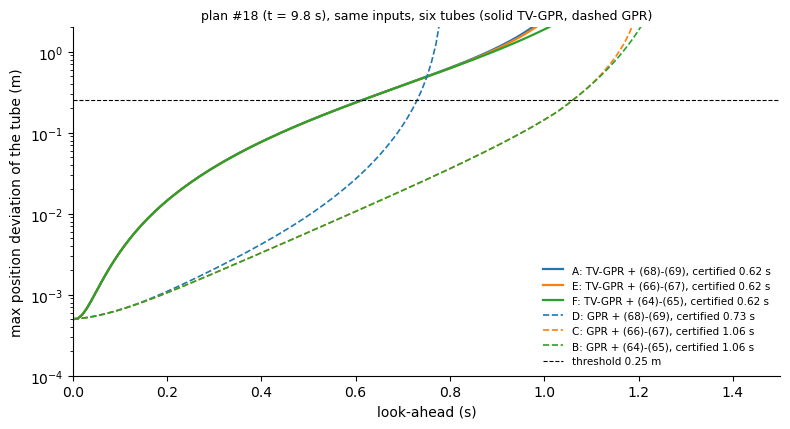

In [8]:
from px4_rta_mm_gpr.concurrency import RolloutConfig, RolloutEngine, RolloutRequest
ref_log = rta.load(sorted(glob.glob(f'{DATA}/numerical/A_windsx0p6_s0.h5'))[0])
md_ = ref_log.metadata
p = ref_log.plan(int(ref_log.plan_seqs[len(ref_log.plan_seqs) // 2]))
fig, ax = plt.subplots(figsize=(8, 4.4))
for v, (eps, emb) in rta.VARIANTS.items():
    eng = RolloutEngine(RolloutConfig(mass=float(md_['mass']), horizon=2.0, timestep=0.01,
                                      ulim_lower=(float(md_['thrust_lo']), -1.0), ulim_upper=(float(md_['thrust_hi']), 1.0),
                                      goal_state=tuple(md_['goal']), x_pert=(5e-4,) * 5, collection_threshold=0.25,
                                      n_obs=9, early_exit=False, min_altitude=0.3, gp_feedforward=True,
                                      gp_epsilon=eps, embedding=emb))
    r = eng.compute(RolloutRequest(t_start=float(p['t_start']), state=p['state0'], K_feedback=p['K_feedback'],
                                   K_reference=p['K_reference'], obs_wy=p['obs_wy'], obs_wz=p['obs_wz'], goal=p['goal']))
    tb, ref = r.reachable_tube, r.rollout_ref
    dev = np.maximum(np.abs(tb[:, 0:2] - ref[:, 0:2]), np.abs(tb[:, 5:7] - ref[:, 0:2])).max(axis=1)
    tt = 0.01 * np.arange(len(dev))
    color = {'uw': '#1f77b4', 'u': '#ff7f0e', 'none': '#2ca02c'}[emb]
    ax.plot(tt, dev, lw=1.6 if eps > 0 else 1.2, ls='-' if eps > 0 else '--', color=color,
            label=f"{SHORT[v]}: {GP_OF[v]} + {EMB_OF[v]}, certified {r.violation_idx * 0.01:.2f} s")
ax.axhline(0.25, color='k', ls='--', lw=0.8, label='threshold 0.25 m')
ax.set_yscale('log'); ax.set_ylim(1e-4, 2); ax.set_xlim(0, 1.5)
ax.set_xlabel('look-ahead (s)'); ax.set_ylabel('max position deviation of the tube (m)')
ax.legend(frameon=False, fontsize=7.5, loc='lower right')
ax.set_title(f"plan #{p['seq']} (t = {p['t_start']:.1f} s), same inputs, six tubes (solid TV-GPR, dashed GPR)", fontsize=9)
fig.tight_layout(); fig.savefig('figures/comparison_tubes.pdf'); fig.savefig('figures/comparison_tubes.png', dpi=150)

## 2. PX4 SITL, δ = 0 (backup LAND on; 3 flights per variant)

In [9]:
def load_sitl(pattern):
    rows = []
    for f in sorted(glob.glob(pattern)):
        with rta.load(f) as L:
            m = rta.comparison_metrics(L, os.path.basename(f))
        m['variant'] = next(k for k in ORDER if k.startswith(os.path.basename(f).split('_')[1] + ':'))
        rows.append(m)
    out = pd.DataFrame(rows)
    out['variant'] = pd.Categorical(out['variant'], ORDER, ordered=True)
    return out

sitl_logs = sorted(glob.glob(f'{DATA}/sitl/cmp_*.h5'))
rows = []
for f in sitl_logs:
    with rta.load(f) as L:
        m = rta.comparison_metrics(L, os.path.basename(f))
    v = next(k for k in ORDER if k.startswith(os.path.basename(f).split('_')[1] + ':'))
    m['variant'] = v
    rows.append(m)
sitl = pd.DataFrame(rows)
sitl['variant'] = pd.Categorical(sitl['variant'], ORDER, ordered=True)
print(f"{len(sitl)} flights; backups engaged: {int(sitl['backup_at_s'].notna().sum())}")
S_COLS = COLS + ['control_period_p99_ms', 'max_attitude_deg']
BETTER.update(control_period_p99_ms='min', max_attitude_deg='min')
s_overall = sitl.groupby('variant', observed=True)[S_COLS].mean()
s_overall.index = [SHORT[v] + ': ' + v.split(': ')[1] for v in s_overall.index]
styled(s_overall, S_COLS)

18 flights; backups engaged: 0


,cert_med_s,cert_p5_s,plans,uncertified_pct,escape_pct,escape_max_m,tube_halfwidth_025,rmse_y,rmse_altitude,lowest_certified_tube,rollout_ms_med,rollout_ms_p99,control_period_p99_ms,max_attitude_deg
A: TV-GPR + (68)-(69),0.542 ▽,0.42,40.7 ▽,0 ★,19.1 ★,0.112,0.0278 ▽,0.0199 ★,0.027,0.859,9.03,11.2,10.6 ★,28.7
E: TV-GPR + (66)-(67),0.543,0.417,40.7 ▽,0 ★,20.1,0.108 ★,0.0269,0.0202,0.0259 ★,0.855,6.07,11.6,10.9,29.9 ▽
F: TV-GPR + (64)-(65),0.543,0.436,39,0 ★,19.7,0.119,0.0234,0.02,0.0304,0.87 ★,6.21,7.94 ★,11.4 ▽,29
D: GPR + (68)-(69),0.777,0.408 ▽,21.7,0 ★,64.6,0.211,0.00825,0.0238,0.032,0.745 ▽,10 ▽,15.4 ▽,11.1,28.3
C: GPR + (66)-(67),0.82,0.503 ★,19.7,0 ★,66.6,0.38 ▽,0.00551,0.027 ▽,0.0421 ▽,0.771,5.14 ★,8.99,10.9,28.5
B: GPR + (64)-(65),0.835 ★,0.5,19.3 ★,0.0343 ▽,71.1 ▽,0.195,0.00315 ★,0.0266,0.0417,0.841,5.34,15.2,10.8,27.8 ★


### The grid (SITL: mean over the 3 flights; worst flight for escape_max_m)

In [10]:
for metric, agg in (('escape_pct', 'mean'), ('escape_max_m', 'max'), ('cert_med_s', 'mean'),
                    ('tube_halfwidth_025', 'mean'), ('rmse_y', 'mean'), ('rmse_altitude', 'mean')):
    display(grid(sitl, metric, agg))

,TV-GPR,GPR
escape_pct (mean),,
(68)-(69),19.1 (A),64.6 (D)
(66)-(67),20.1 (E),66.6 (C)
(64)-(65),19.7 (F),71.1 (B)


,TV-GPR,GPR
escape_max_m (max),,
(68)-(69),0.12 (A),0.274 (D)
(66)-(67),0.121 (E),0.797 (C)
(64)-(65),0.15 (F),0.261 (B)


,TV-GPR,GPR
cert_med_s (mean),,
(68)-(69),0.542 (A),0.777 (D)
(66)-(67),0.543 (E),0.82 (C)
(64)-(65),0.543 (F),0.835 (B)


,TV-GPR,GPR
tube_halfwidth_025 (mean),,
(68)-(69),0.0278 (A),0.00825 (D)
(66)-(67),0.0269 (E),0.00551 (C)
(64)-(65),0.0234 (F),0.00315 (B)


,TV-GPR,GPR
rmse_y (mean),,
(68)-(69),0.0199 (A),0.0238 (D)
(66)-(67),0.0202 (E),0.027 (C)
(64)-(65),0.02 (F),0.0266 (B)


,TV-GPR,GPR
rmse_altitude (mean),,
(68)-(69),0.027 (A),0.032 (D)
(66)-(67),0.0259 (E),0.0421 (C)
(64)-(65),0.0304 (F),0.0417 (B)


### Spread over the 3 flights (mean ± std)

In [11]:
g = sitl.groupby('variant', observed=True)[['cert_med_s', 'plans', 'escape_pct', 'escape_max_m', 'rmse_y', 'rmse_altitude']]
ms = g.mean().round(3).astype(str) + ' ± ' + g.std().round(3).astype(str)
ms.index = [SHORT[v] for v in ms.index]
ms

,cert_med_s,plans,escape_pct,escape_max_m,rmse_y,rmse_altitude
A,0.542 ± 0.008,40.667 ± 2.082,19.09 ± 1.726,0.112 ± 0.008,0.02 ± 0.002,0.027 ± 0.002
E,0.543 ± 0.006,40.667 ± 0.577,20.083 ± 0.878,0.108 ± 0.02,0.02 ± 0.0,0.026 ± 0.002
F,0.543 ± 0.006,39.0 ± 1.0,19.73 ± 1.326,0.119 ± 0.034,0.02 ± 0.002,0.03 ± 0.004
D,0.777 ± 0.045,21.667 ± 0.577,64.596 ± 1.748,0.211 ± 0.057,0.024 ± 0.001,0.032 ± 0.008
C,0.82 ± 0.036,19.667 ± 1.155,66.567 ± 8.006,0.38 ± 0.364,0.027 ± 0.006,0.042 ± 0.021
B,0.835 ± 0.013,19.333 ± 0.577,71.06 ± 15.876,0.195 ± 0.065,0.027 ± 0.005,0.042 ± 0.011


### Relative to A

In [12]:
styled(s_overall.div(s_overall.iloc[0]), S_COLS, fmt='{:.2f}x')

,cert_med_s,cert_p5_s,plans,uncertified_pct,escape_pct,escape_max_m,tube_halfwidth_025,rmse_y,rmse_altitude,lowest_certified_tube,rollout_ms_med,rollout_ms_p99,control_period_p99_ms,max_attitude_deg
A: TV-GPR + (68)-(69),1.00x ▽,1.00x,1.00x ▽,-,1.00x ★,1.00x,1.00x ▽,1.00x ★,1.00x,1.00x,1.00x,1.00x,1.00x ★,1.00x
E: TV-GPR + (66)-(67),1.00x,0.99x,1.00x ▽,-,1.05x,0.97x ★,0.96x,1.02x,0.96x ★,1.00x,0.67x,1.03x,1.03x,1.04x ▽
F: TV-GPR + (64)-(65),1.00x,1.04x,0.96x,-,1.03x,1.06x,0.84x,1.01x,1.13x,1.01x ★,0.69x,0.71x ★,1.08x ▽,1.01x
D: GPR + (68)-(69),1.43x,0.97x ▽,0.53x,-,3.38x,1.90x,0.30x,1.20x,1.19x,0.87x ▽,1.11x ▽,1.37x ▽,1.05x,0.99x
C: GPR + (66)-(67),1.51x,1.20x ★,0.48x,-,3.49x,3.41x ▽,0.20x,1.36x ▽,1.56x ▽,0.90x,0.57x ★,0.80x,1.03x,0.99x
B: GPR + (64)-(65),1.54x ★,1.19x,0.48x ★,-,3.72x ▽,1.75x,0.11x ★,1.34x,1.54x,0.98x,0.59x,1.35x,1.03x,0.97x ★


### Per flight

In [13]:
sitl.sort_values(['variant', 'flight'])[['flight', 'variant', 'cert_med_s', 'plans', 'uncertified_pct', 'escape_pct',
                                         'escape_max_m', 'rmse_y', 'rmse_altitude', 'backup_at_s']]

,flight,variant,cert_med_s,plans,uncertified_pct,escape_pct,escape_max_m,rmse_y,rmse_altitude,backup_at_s
0,cmp_A_1.h5,A: TV-GPR + (68)-(69),0.535,40,0.000,20.850,0.109,0.022,0.029,NaN
1,cmp_A_2.h5,A: TV-GPR + (68)-(69),0.540,39,0.000,17.400,0.120,0.020,0.027,NaN
2,cmp_A_3.h5,A: TV-GPR + (68)-(69),0.550,43,0.000,19.019,0.105,0.018,0.025,NaN
12,cmp_E_1.h5,E: TV-GPR + (66)-(67),0.540,40,0.000,19.250,0.121,0.020,0.028,NaN
13,cmp_E_2.h5,E: TV-GPR + (66)-(67),0.550,41,0.000,21.000,0.119,0.020,0.027,NaN
14,cmp_E_3.h5,E: TV-GPR + (66)-(67),0.540,41,0.000,20.000,0.085,0.020,0.023,NaN
15,cmp_F_1.h5,F: TV-GPR + (64)-(65),0.540,38,0.000,20.450,0.150,0.020,0.034,NaN
16,cmp_F_2.h5,F: TV-GPR + (64)-(65),0.550,40,0.000,20.540,0.082,0.022,0.026,NaN
17,cmp_F_3.h5,F: TV-GPR + (64)-(65),0.540,39,0.000,18.200,0.124,0.018,0.032,NaN
9,cmp_D_1.h5,D: GPR + (68)-(69),0.730,22,0.000,66.000,0.274,0.024,0.040,NaN


## 3. PX4 SITL with the 5 cm model-mismatch margin (the default; 3 flights per variant)
$\delta = 0.05$ m widens the tube's starting box and adds 5 cm to the threshold. It covers the planar
model's short-term mismatch with the full PX4 vehicle, which put even the TV-GPR flights outside their
tube in the first moments of each plan (section 2).

In [14]:
sitl_m = load_sitl(f'{DATA}/sitl/cmpm_*.h5')
print(f"{len(sitl_m)} flights; backups engaged: {int(sitl_m['backup_at_s'].notna().sum())}")
sm_overall = sitl_m.groupby('variant', observed=True)[S_COLS].mean()
sm_overall.index = [SHORT[v] + ': ' + v.split(': ')[1] for v in sm_overall.index]
styled(sm_overall, S_COLS)

18 flights; backups engaged: 0


,cert_med_s,cert_p5_s,plans,uncertified_pct,escape_pct,escape_max_m,tube_halfwidth_025,rmse_y,rmse_altitude,lowest_certified_tube,rollout_ms_med,rollout_ms_p99,control_period_p99_ms,max_attitude_deg
A: TV-GPR + (68)-(69),0.343 ★,0.279 ★,59,0,0 ★,0 ★,0.152 ▽,0.013,0.0175 ▽,0.767,3.94,5.32,10.3,27.8 ★
E: TV-GPR + (66)-(67),0.343 ★,0.279 ★,59,0,0 ★,0.000224,0.151,0.0131 ▽,0.016,0.768 ★,3.77,4.38 ★,10.2 ★,28
F: TV-GPR + (64)-(65),0.343 ★,0.279,58.7,0,0 ★,0 ★,0.152,0.0121,0.0151,0.762,4.01 ▽,4.65,10.2,28.2
D: GPR + (68)-(69),0.17 ▽,0.06 ▽,93.7 ▽,0,0 ★,0 ★,0.122 ★,0.00683 ★,0.00868 ★,0.647 ▽,3.49,5.8 ▽,10.8 ▽,28.7 ▽
C: GPR + (66)-(67),0.285,0.178,54.3,0,0 ★,0 ★,0.133,0.0109,0.0116,0.697,3.3 ★,4.92,10.6,27.9
B: GPR + (64)-(65),0.287,0.178,54 ★,0,0.0167 ▽,0.000869 ▽,0.136,0.0117,0.011,0.702,3.43,5.55,10.3,28.5


In [15]:
for metric, agg in (('escape_pct', 'mean'), ('escape_max_m', 'max'), ('cert_med_s', 'mean'),
                    ('tube_halfwidth_025', 'mean'), ('rmse_y', 'mean'), ('rmse_altitude', 'mean')):
    display(grid(sitl_m, metric, agg))

,TV-GPR,GPR
escape_pct (mean),,
(68)-(69),0 (A),0 (D)
(66)-(67),0 (E),0 (C)
(64)-(65),0 (F),0.0167 (B)


,TV-GPR,GPR
escape_max_m (max),,
(68)-(69),0 (A),0 (D)
(66)-(67),0.000673 (E),0 (C)
(64)-(65),0 (F),0.00261 (B)


,TV-GPR,GPR
cert_med_s (mean),,
(68)-(69),0.343 (A),0.17 (D)
(66)-(67),0.343 (E),0.285 (C)
(64)-(65),0.343 (F),0.287 (B)


,TV-GPR,GPR
tube_halfwidth_025 (mean),,
(68)-(69),0.152 (A),0.122 (D)
(66)-(67),0.151 (E),0.133 (C)
(64)-(65),0.152 (F),0.136 (B)


,TV-GPR,GPR
rmse_y (mean),,
(68)-(69),0.013 (A),0.00683 (D)
(66)-(67),0.0131 (E),0.0109 (C)
(64)-(65),0.0121 (F),0.0117 (B)


,TV-GPR,GPR
rmse_altitude (mean),,
(68)-(69),0.0175 (A),0.00868 (D)
(66)-(67),0.016 (E),0.0116 (C)
(64)-(65),0.0151 (F),0.011 (B)


### δ = 0 vs the 5 cm margin, per variant

In [16]:
cmp = pd.DataFrame({
    'outside tube, δ=0 (%)': sitl.groupby('variant', observed=True)['escape_pct'].mean(),
    'outside tube, margin (%)': sitl_m.groupby('variant', observed=True)['escape_pct'].mean(),
    'worst, δ=0 (m)': sitl.groupby('variant', observed=True)['escape_max_m'].max(),
    'worst, margin (m)': sitl_m.groupby('variant', observed=True)['escape_max_m'].max(),
    'horizon, δ=0 (s)': sitl.groupby('variant', observed=True)['cert_med_s'].mean(),
    'horizon, margin (s)': sitl_m.groupby('variant', observed=True)['cert_med_s'].mean(),
    'RMSE y, margin (m)': sitl_m.groupby('variant', observed=True)['rmse_y'].mean(),
})
cmp.index = [SHORT[v] + ': ' + v.split(': ')[1] for v in cmp.index]
cmp.round(3)

,"outside tube, δ=0 (%)","outside tube, margin (%)","worst, δ=0 (m)","worst, margin (m)","horizon, δ=0 (s)","horizon, margin (s)","RMSE y, margin (m)"
A: TV-GPR + (68)-(69),19.090,0.000,0.120,0.000,0.542,0.343,0.013
E: TV-GPR + (66)-(67),20.083,0.000,0.121,0.001,0.543,0.343,0.013
F: TV-GPR + (64)-(65),19.730,0.000,0.150,0.000,0.543,0.343,0.012
D: GPR + (68)-(69),64.596,0.000,0.274,0.000,0.777,0.170,0.007
C: GPR + (66)-(67),66.567,0.000,0.797,0.000,0.820,0.285,0.011
B: GPR + (64)-(65),71.060,0.017,0.261,0.003,0.835,0.287,0.012


### Certified horizon of every plan

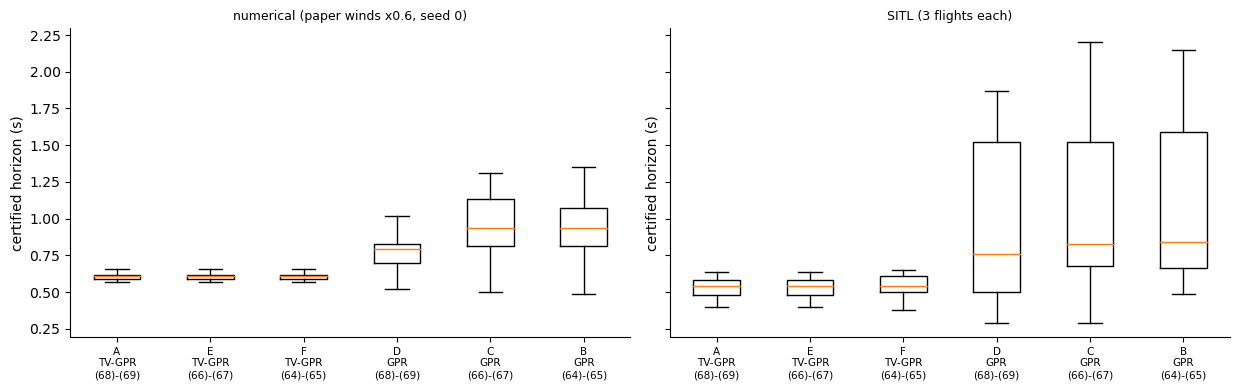

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12.5, 4.0), sharey=True)
for ax, (label, frame, glob_pat) in zip(axs, (('numerical (paper winds x0.6, seed 0)', num, None), ('SITL (3 flights each)', sitl, None))):
    data = []
    for v in ORDER:
        flights = frame[frame['variant'] == v]['flight']
        vals = []
        for fl in flights:
            path = (f'{DATA}/numerical/{fl}.h5' if label.startswith('num') else f'{DATA}/sitl/{fl}')
            if os.path.exists(path):
                with rta.load(path) as L:
                    t0 = 15.0 if L.metadata.get('platform') != 'numerical_sim' else 0.0
                    vals += [rta.certified_rows(q) * q['dt'] for q in (L.plan(int(s)) for s in L.plan_seqs)
                             if not q.get('warmup', False) and q['t_start'] >= t0]
        data.append(vals if vals else [np.nan])
    ax.boxplot(data, labels=[f"{SHORT[v]}\n{GP_OF[v]}\n{EMB_OF[v]}" for v in ORDER], showfliers=False)
    ax.tick_params(axis='x', labelsize=7.5)
    ax.set_title(label, fontsize=9); ax.set_ylabel('certified horizon (s)')
fig.tight_layout(); fig.savefig('figures/comparison_horizons.pdf'); fig.savefig('figures/comparison_horizons.png', dpi=150)

### Safety: how often, and how far, the vehicle leaves its certified tube

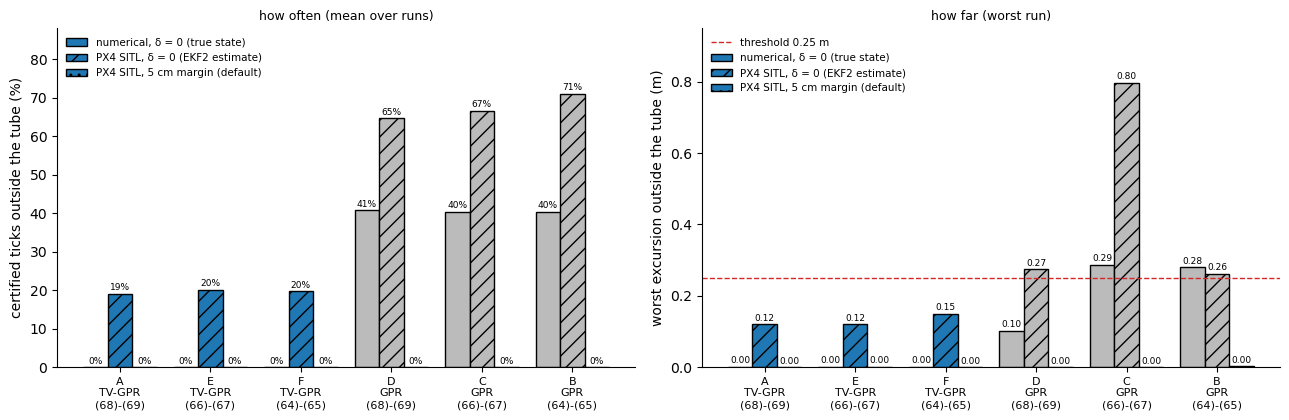

In [18]:
wind = num[num['case'] != 'calm']
fig, axs = plt.subplots(1, 2, figsize=(13, 4.3))
x = np.arange(len(ORDER)); w = 0.27
colors = ['#1f77b4' if GP_OF[v] == 'TV-GPR' else '#bbbbbb' for v in ORDER]
for ax, col, ylabel in ((axs[0], 'escape_pct', 'certified ticks outside the tube (%)'),
                        (axs[1], 'escape_max_m', 'worst excursion outside the tube (m)')):
    agg = 'mean' if col == 'escape_pct' else 'max'
    n_vals = [getattr(wind[wind['variant'] == v][col], agg)() for v in ORDER]
    s_vals = [getattr(sitl[sitl['variant'] == v][col], agg)() for v in ORDER]
    m_vals = [getattr(sitl_m[sitl_m['variant'] == v][col], agg)() for v in ORDER]
    fmt = '%.0f%%' if col == 'escape_pct' else '%.2f'
    ax.bar_label(ax.bar(x - w, n_vals, w, color=colors, edgecolor='k', label='numerical, δ = 0 (true state)'),
                 fmt=fmt, fontsize=6.5, padding=1)
    ax.bar_label(ax.bar(x, s_vals, w, color=colors, edgecolor='k', hatch='//', label='PX4 SITL, δ = 0 (EKF2 estimate)'),
                 fmt=fmt, fontsize=6.5, padding=1)
    ax.bar_label(ax.bar(x + w, m_vals, w, color=colors, edgecolor='k', hatch='..', label='PX4 SITL, 5 cm margin (default)'),
                 fmt=fmt, fontsize=6.5, padding=1)
    ax.set_xticks(x, [f"{SHORT[v]}\n{GP_OF[v]}\n{EMB_OF[v]}" for v in ORDER], fontsize=8)
    ax.set_ylabel(ylabel)
    if col == 'escape_max_m':
        ax.axhline(0.25, color='tab:red', ls='--', lw=1, label='threshold 0.25 m')
    ax.legend(frameon=False, fontsize=7.5, loc='upper left')
axs[0].set_ylim(0, 88); axs[1].set_ylim(0, 0.95); axs[0].set_title('how often (mean over runs)', fontsize=9); axs[1].set_title('how far (worst run)', fontsize=9)
fig.tight_layout(); fig.savefig('figures/comparison_escapes.pdf'); fig.savefig('figures/comparison_escapes.png', dpi=150)

## Conclusions

**Where each result comes from.** The numerical simulation has the paper's *evolving* wind (it drifts over
time and varies with position) and the exact vehicle model. The PX4 SITL world used here has **no wind**
(`default.sdf`: `enable_wind` false): the only disturbance the GPs learn there is a steady offset (the
thrust map, about −1 N vertically) plus the planar model's mismatch with the full PX4 vehicle.

* **The GP decides whether the certificate is true (numerical, drifting wind).** With every embedding
  system, the time-invariant GP produces tubes about 10× thinner that certify 30-40 % further ahead, but
  it is *confidently wrong* about a wind that drifts over time: the true state leaves its certified box on
  about 40 % of certified ticks (27-52 % per run), by up to 0.29 m, more than the 0.25 m threshold itself.
  With TV-GPR the true state stayed inside its certified box in every run with every embedding (worst
  0.9-1.2 mm, the 10 ms Euler stepping of the tube).
* **The three embedding systems with TV-GPR are practically equivalent (numerical).** (68)-(69), (66)-(67)
  and (64)-(65) certify the same horizon (0.59 s median) with the same tube widths, the same tracking and no
  escapes. For this vehicle (64)-(65) coincides with (66)-(67) ($[M_u](K[e]) = ([M_u]K)[e]$, a constant
  selector matrix), and the first-order disturbance term of (68)-(69) buys no measurable tightening, because
  the TV-GPR's growing $\sigma$ over the look-ahead dominates the tube's growth. (66)-(67) is the cheapest
  (4.3 vs 6.9 ms per rollout).
* **SITL with δ = 0 (section 2) measures the model mismatch, not the wind model.** Every variant leaves
  its tube in the first moments of each plan: the TV-GPR variants about 20 % of the time (up to 0.12-0.15 m),
  the GPR variants 65-71 % (up to 0.80 m) because their tubes are thinner, not because their wind model is
  wrong (there is no drifting wind to be wrong about).
* **SITL with the 5 cm model-mismatch margin (section 3, the default): all six variants stay inside their
  tube** (0-0.02 % of the time, worst 3 mm), and none needed the LAND backup. The TV-GPR variants certify
  the longest (0.34 s against 0.17-0.29 s for the GPR variants) and track at 12-13 mm.
* **What SITL cannot show yet.** The failure of the time-invariant GP needs a wind that changes over time;
  the windless (or constant-wind) Gazebo world cannot produce it. A SITL test of that claim needs a
  time-varying wind in Gazebo.
* **Cost.** One rollout takes 3-10 ms for every variant, far below the certified horizon.
